<a href="https://colab.research.google.com/github/Gh4n5kH/mugni-data-science-2024/blob/main/Pertemuan9_Mugni_240401010355.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Langkah 1: Load & EDA Singkat**

In [17]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(f"Jumlah sampel : {X.shape[0]}")
print(f"Jumlah fitur  : {X.shape[1]}")
print(f"Shape dataset : {X.shape}")

# Distribusi target
target_names = {0: "Malignant", 1: "Benign"}

target_distribution = (
    y.map(target_names)
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Jumlah")
)

target_distribution["Persentase"] = (
    target_distribution["Jumlah"] / len(y) * 100
).round(2)

print("\nDistribusi Target:")
print(target_distribution)

# Matriks korelasi
corr_matrix = X.corr()

print("\n5x5 Matriks Korelasi:")
print(corr_matrix.iloc[:5, :5].round(2))

# Korelasi tertinggi antar fitur
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

corr_pairs = (
    corr_matrix.where(mask)
    .stack()
    .sort_values(ascending=False)
)

print("\n10 Pasangan Fitur dengan Korelasi Tertinggi:")
print(corr_pairs.head(10).round(3))

INFORMASI DATASET
Jumlah sampel : 569
Jumlah fitur  : 30
Shape dataset : (569, 30)

Distribusi Target:
       Class  Jumlah  Persentase
0     Benign     357       62.74
1  Malignant     212       37.26

5x5 Matriks Korelasi:
                 mean radius  mean texture  mean perimeter  mean area  \
mean radius             1.00          0.32            1.00       0.99   
mean texture            0.32          1.00            0.33       0.32   
mean perimeter          1.00          0.33            1.00       0.99   
mean area               0.99          0.32            0.99       1.00   
mean smoothness         0.17         -0.02            0.21       0.18   

                 mean smoothness  
mean radius                 0.17  
mean texture               -0.02  
mean perimeter              0.21  
mean area                   0.18  
mean smoothness             1.00  

10 Pasangan Fitur dengan Korelasi Tertinggi:
mean radius      mean perimeter     0.998
worst radius     worst perimeter    0.

**Langkah 2: Preprocessing**

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("TRAIN-TEST SPLIT")
print("=" * 50)
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {len(y_train)}")
print(f"y_test  : {len(y_test)}")


# Distribusi Target Setelah Split
print("\nDistribusi Target Training:")
print(pd.Series(y_train).value_counts(normalize=True).rename({
    0: "Malignant",
    1: "Benign"
}).round(3))

print("\nDistribusi Target Testing:")
print(pd.Series(y_test).value_counts(normalize=True).rename({
    0: "Malignant",
    1: "Benign"
}).round(3))


# Standardisasi Fitur
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("\nStandardisasi selesai.")
print(f"Shape X_train_s : {X_train_s.shape}")
print(f"Shape X_test_s  : {X_test_s.shape}")

TRAIN-TEST SPLIT
X_train : (455, 30)
X_test  : (114, 30)
y_train : 455
y_test  : 114

Distribusi Target Training:
target
Benign       0.626
Malignant    0.374
Name: proportion, dtype: float64

Distribusi Target Testing:
target
Benign       0.632
Malignant    0.368
Name: proportion, dtype: float64

Standardisasi selesai.
Shape X_train_s : (455, 30)
Shape X_test_s  : (114, 30)


**Langkah 3: Latih Logistic Regression**

In [21]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Logistic Regression
log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_model.fit(X_train_s, y_train)

# Prediksi
y_pred_log = log_model.predict(X_test_s)

# Koefisien Model
coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
})

# Urutkan berdasarkan pengaruh terbesar
coef_df["Abs_Koefisien"] = coef_df["Koefisien"].abs()
coef_df = coef_df.sort_values(
    by="Abs_Koefisien",
    ascending=False
)

print("=" * 60)
print("INTERCEPT MODEL")
print("=" * 60)
print(log_model.intercept_[0])

print("\n" + "=" * 60)
print("10 FITUR PALING BERPENGARUH")
print("=" * 60)
print(coef_df[["Fitur", "Koefisien"]].head(10))

# Interpretasi
print("\nInterpretasi:")

for _, row in coef_df.head(10).iterrows():
    arah = "meningkatkan peluang kelas Benign (1)" if row["Koefisien"] > 0 \
        else "meningkatkan peluang kelas Malignant (0)"

    print(f"- {row['Fitur']}: koefisien = {row['Koefisien']:.4f} → {arah}")

INTERCEPT MODEL
0.3022075735370281

10 FITUR PALING BERPENGARUH
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616
28        worst symmetry  -0.939181
13            area error  -0.929104
26       worst concavity  -0.823151
22       worst perimeter  -0.763220
24      worst smoothness  -0.746625

Interpretasi:
- worst texture: koefisien = -1.2551 → meningkatkan peluang kelas Malignant (0)
- radius error: koefisien = -1.0830 → meningkatkan peluang kelas Malignant (0)
- worst concave points: koefisien = -0.9537 → meningkatkan peluang kelas Malignant (0)
- worst area: koefisien = -0.9478 → meningkatkan peluang kelas Malignant (0)
- worst radius: koefisien = -0.9476 → meningkatkan peluang kelas Malignant (0)
- worst symmetry: koefisien = -0.9392 → meningkatkan peluang kelas Malignant (0)
- area error: koefisien = -0.9291 → mening

**Langkah 4: Latih Decision Tree**

DECISION TREE
Model berhasil dilatih.
Kedalaman pohon : 4
Jumlah leaf     : 11


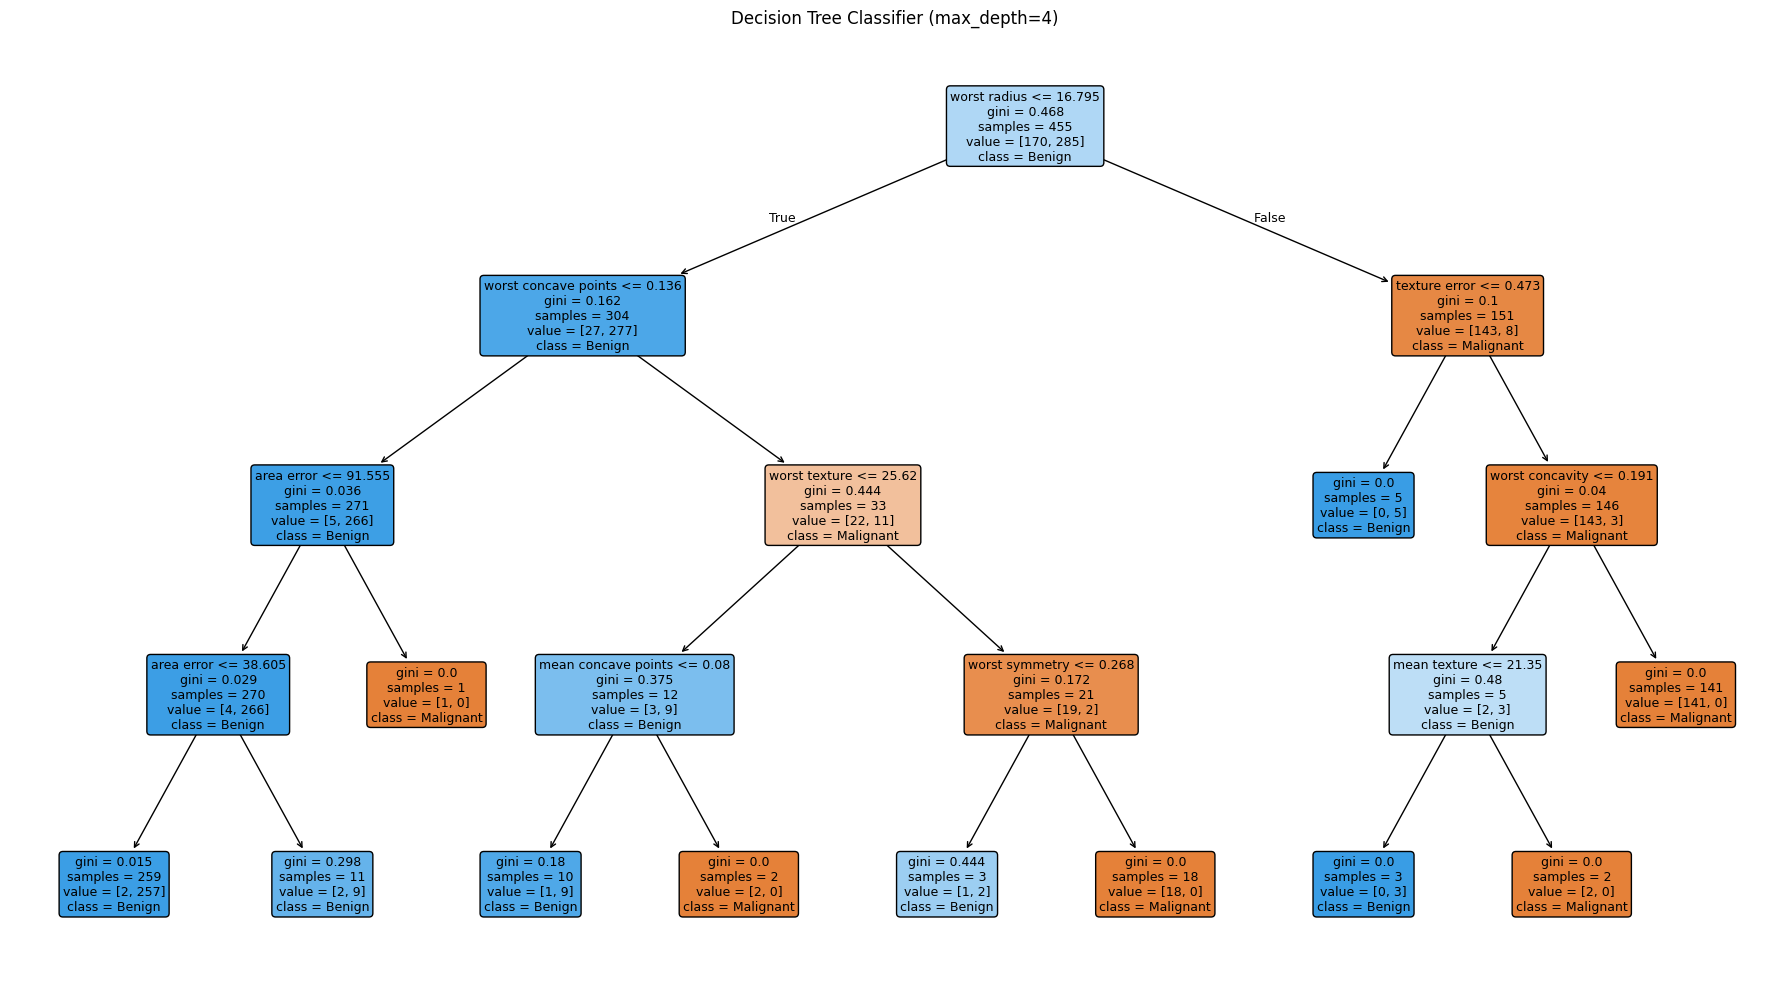


10 Feature Importance Terbesar:
                   Fitur  Importance
20          worst radius    0.733548
27  worst concave points    0.122028
11         texture error    0.045785
21         worst texture    0.032319
26       worst concavity    0.017161
7    mean concave points    0.013327
13            area error    0.012704
1           mean texture    0.011846
28        worst symmetry    0.011282
3              mean area    0.000000


In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

# Decision Tree
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Training model
tree_model.fit(X_train, y_train)

# Prediksi
y_pred_tree = tree_model.predict(X_test)

print("=" * 60)
print("DECISION TREE")
print("=" * 60)
print("Model berhasil dilatih.")
print(f"Kedalaman pohon : {tree_model.get_depth()}")
print(f"Jumlah leaf     : {tree_model.get_n_leaves()}")

# Visualisasi Pohon
plt.figure(figsize=(18, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Classifier (max_depth=4)")
plt.tight_layout()
plt.show()

# Feature Importance
importance_df = (
    pd.DataFrame({
        "Fitur": X.columns,
        "Importance": tree_model.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
)

print("\n10 Feature Importance Terbesar:")
print(importance_df.head(10))

**Langkah 5: Evaluasi & Bandingkan**

In [25]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd

# Evaluasi Model
results = []

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree
}

for name, y_pred in models.items():

    cm = confusion_matrix(y_test, y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("Confusion Matrix")
    print(cm)

    print(f"\nAccuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-Score : {f1:.3f}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# Ringkasan Performa
results_df = pd.DataFrame(results)

print("\n")
print("=" * 60)
print("PERBANDINGAN PERFORMA MODEL")
print("=" * 60)

print(results_df.round(3))

# Model dengan Recall Terbaik
best_recall = results_df.loc[
    results_df["Recall"].idxmax()
]

print("\nModel dengan Recall tertinggi:")
print(f"{best_recall['Model']} ({best_recall['Recall']:.3f})")

Logistic Regression
Confusion Matrix
[[41  1]
 [ 1 71]]

Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986
Decision Tree
Confusion Matrix
[[39  3]
 [ 4 68]]

Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


PERBANDINGAN PERFORMA MODEL
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.982      0.986   0.986     0.986
1        Decision Tree     0.939      0.958   0.944     0.951

Model dengan Recall tertinggi:
Logistic Regression (0.986)


**Kesimpulan:**

Berdasarkan hasil evaluasi, **Logistic Regression** memiliki nilai **Recall sebesar 0.986**, lebih tinggi dibandingkan **Decision Tree** yang memperoleh **0.944**. Hal ini menunjukkan bahwa Logistic Regression lebih baik dalam mendeteksi pasien yang benar-benar menderita kanker, sehingga lebih sesuai digunakan untuk membantu proses diagnosis medis.

Recall merupakan metrik yang paling penting pada kasus diagnosis kanker karena mengukur kemampuan model dalam mengidentifikasi seluruh pasien yang benar-benar positif. Nilai Recall yang tinggi akan mengurangi jumlah **False Negative**, yaitu kondisi ketika pasien yang sebenarnya menderita kanker diprediksi tidak memiliki kanker. Kesalahan ini dapat menyebabkan keterlambatan diagnosis dan penanganan, sehingga berpotensi meningkatkan risiko terhadap keselamatan pasien.

Meskipun kedua model memiliki performa yang baik, **Logistic Regression** juga memperoleh nilai **Accuracy** dan **F1-Score** yang sedikit lebih tinggi dibandingkan **Decision Tree**. Oleh karena itu, berdasarkan hasil evaluasi tersebut, Logistic Regression dapat dianggap sebagai model yang lebih baik untuk klasifikasi kanker payudara pada dataset ini.